<a href="https://colab.research.google.com/github/nhongtat-a11y/codefinity-deep-learning-with-tensorflow/blob/master/Copy_of_object_detection_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection: Custom Keras Model & YOLO Fine-tuning

## Introduction
In this chapter, we'll learn how to create a custom object detection model and how to use pre-trained YOLO model. Specifically, we'll focus on detecting only the **"person"** class using our own dataset. We'll explore both the idea of building a model from scratch and why using **transfer learning** with pretrained models like YOLO is often the smarter choice.


## Mount Drive Storage

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Libraries

In [ ]:
!pip install git+https://github.com/codefinity-arsenii-dr/codefinity_test_object_detection.git


  Cloning https://github.com/codefinity-arsenii-dr/codefinity_test_object_detection.git to /tmp/pip-req-build-kpecjk29
  Running command git clone --filter=blob:none --quiet https://github.com/codefinity-arsenii-dr/codefinity_test_object_detection.git /tmp/pip-req-build-kpecjk29
  Resolved https://github.com/codefinity-arsenii-dr/codefinity_test_object_detection.git to commit 3ea6bd99580f0a1434c54b49eafb0f3220a36895
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.5 MB/s eta 0:00:00
  Created wheel for test-obj-det: filename=test_obj_det-1.0.0-py3-none-any.whl size=9782 sha256=9d522d2f2e069acb380e6a93c6bafbd5f528fd2df2983cab132cf8998be1be91
  Stored in directory: /tmp/pip-ephem-wheel-cache-upxae1e1/wheels/32/59/cf/7a2494db0fa8c3ff077b741c2510abe81cd6873ca23e128d0f
Successfully built test-obj-det


In [ ]:
!pip install keras_cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 23.8 MB/s eta 0:00:00


In [ ]:
import os
import random
import requests

import cv2
import numpy as np
import matplotlib.pyplot as plt

import keras_cv
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import ultralytics
from ultralytics import YOLO

import warnings as w
w.simplefilter('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from test_obj_det import *
from test_obj_det.test import *

## Load and Preprocess Dataset

Before running this cell, make sure you've uploaded the dataset folder to your Google Drive and mounted it using `drive.mount(...)`. This function doesn't accept a Google Drive URL — it needs a local path like `/content/drive/MyDrive/...`. Double-check that the folder contains the correct subdirectories (for example, `images/train`), and update the path below accordingly.

In [ ]:
# === 1. Load the dataset ===
# TODO: Load training and validation data (images, bounding boxes, and original shapes)

# Replace '/content/drive/MyDrive/images/train' with the path to your dataset's root folder.
# For example, if your dataset is structured as '/content/drive/MyDrive/my_dataset_folder/images/train',
# then the path below should be '/content/drive/MyDrive/my_dataset_folder'.
train_images, train_labels, train_shapes = load_data("/content/drive/MyDrive/dataset", split="train")
val_images, val_labels, val_shapes = load_data("/content/drive/MyDrive/dataset", split="val")

In [ ]:
hint1()


Use the `load_data()` function twice — once with `split="train"` and once with `split="val"`.
Make sure to assign the output to three separate variables each time, like:
images, labels, shapes = load_data(...)


In [ ]:
solution1()

train_images , train_labels , train_shapes = load_data ( "/path/to/dataset/data" , split = "train" ) 
 val_images , val_labels , val_shapes = load_data ( "/path/to/dataset/data" , split = "val" )

In [ ]:
check1(train_images, train_labels, train_shapes, val_images, val_labels, val_shapes)

Well done! Here's your first key part: LDA92P

In [ ]:
# === 2. Normalize the images ===
# TODO: Normalize image pixel values to the range [0, 1]

train_images_norm = train_images / 255.0
val_images_norm = val_images / 255.0

In [ ]:
hint2()


Images should be normalized so that pixel values lie between 0 and 1.
You can achieve this by dividing the pixel values by 255.0.
Create two variables: one for training (`train_images_norm`) and one for validation (`val_images_norm`).


In [ ]:
solution2()

train_images_norm = train_images / 255.0 
 val_images_norm = val_images / 255.0

In [ ]:
check2(train_images_norm, val_images_norm)

Great job! Here's your next key part: MXR84N

## How to Create Own Object Detection Model with Keras

In [ ]:
# === 3. Build the CNN model ===
# TODO: Define a CNN that has 128x128 3-channel input and outputs 4 values (x, y, w, h) with sigmoid activation.

def build_model():
    model = keras.Sequential([
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=(128,128, 3)),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(8, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(8, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(4, activation='sigmoid')
    ])
    return model

In [ ]:
hint3()


You're building a CNN for predicting 4 normalized bounding box coordinates (x, y, w, h).

- Start with 4 convolutional blocks (Conv2D + MaxPooling2D)
- The input shape is (128, 128, 3)
- Use a Dense layer with 1024 units before the output
- Final layer should be `Dense(4, activation='sigmoid')` to output normalized values


In [ ]:
solution3()

def build_model (): 
 model = keras . Sequential ([ 
 layers . Conv2D ( 32 , ( 3 , 3 ), activation = 'relu' , input_shape = ( 128 , 128 , 3 )), 
 layers . MaxPooling2D ( 2 , 2 ), 
 layers . Conv2D ( 64 , ( 3 , 3 ), activation = 'relu' ), 
 layers . MaxPooling2D ( 2 , 2 ), 
 layers . Conv2D ( 64 , ( 3 , 3 ), activation = 'relu' ), 
 layers . MaxPooling2D ( 2 , 2 ), 
 layers . Conv2D ( 128 , ( 3 , 3 ), activation = 'relu' ), 
 layers . MaxPooling2D ( 2 , 2 ), 
 layers . Flatten (), 
 layers . Dense ( 1024 , activation = 'relu' ), 
 layers . Dropout ( 0.3 ), 
 layers . Dense ( 4 , activation = 'sigmoid' ) 
 ]) 
 return model

In [ ]:
# === 4. Load or train the model ===
# TODO: Compile the model, train if no weights exist, or load existing weights.

def build_load_model(X_train, y_train, weights_path, optimizer, loss, metrics):
    model = build_model()
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    if os.path.exists(weights_path):
        print("Loading weights from", weights_path)
        model.load_weights(weights_path)
    else:
        model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2)
        model.save_weights(weights_path)

    return model

In [ ]:
hint4()


- Use `.compile()` before training or loading weights.
- If weights already exist, use `.load_weights()`.
- Otherwise, train the model using `.fit()` and save weights with `.save_weights()`.


In [ ]:
solution4()

def build_load_model ( X_train , y_train , weights_path , optimizer , loss , metrics ): 
 model = build_model () 
 model . compile ( optimizer = optimizer , loss = loss , metrics = metrics ) 

 if os . path . exists ( weights_path ): 
 model . load_weights ( weights_path ) 
 else : 
 model . fit ( X_train , y_train , epochs = 10 , batch_size = 32 , validation_split = 0.2 ) 
 model . save_weights ( weights_path ) 

 return model

In [ ]:
# === 5. Initialize and compile the model ===
# TODO: Fill in the correct parameters for training
weights="/content/drive/MyDrive/Models/my_model.weights.h5"

print("X:", len(train_images_norm))
print("Y:", len(train_labels))

model = build_load_model(
    X_train=train_images_norm,
    y_train=train_labels,
    weights_path=weights,
    optimizer="adam",
    loss="huber",
    metrics=["mae"]
)

X: 440
Y: 440
Loading weights from /content/drive/MyDrive/Models/my_model.weights.h5


In [ ]:
hint5()


- Call `build_load_model()` with real training data and valid parameters for training.


In [ ]:
solution5()

model = build_load_model ( 
 X_train = train_images_norm , 
 y_train = train_labels , 
 weights_path = "/path/to/weights/custom_object_detector.weights.h5" , 
 optimizer = 'adam' , 
 loss = 'mse' , 
 metrics = [ "mae" ] 
 )

In [ ]:
check345(model, weights_path=weights)

Model architecture and setup look good! Next keys: 7XPB9R, TT66X5, JIO907

## Vizualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


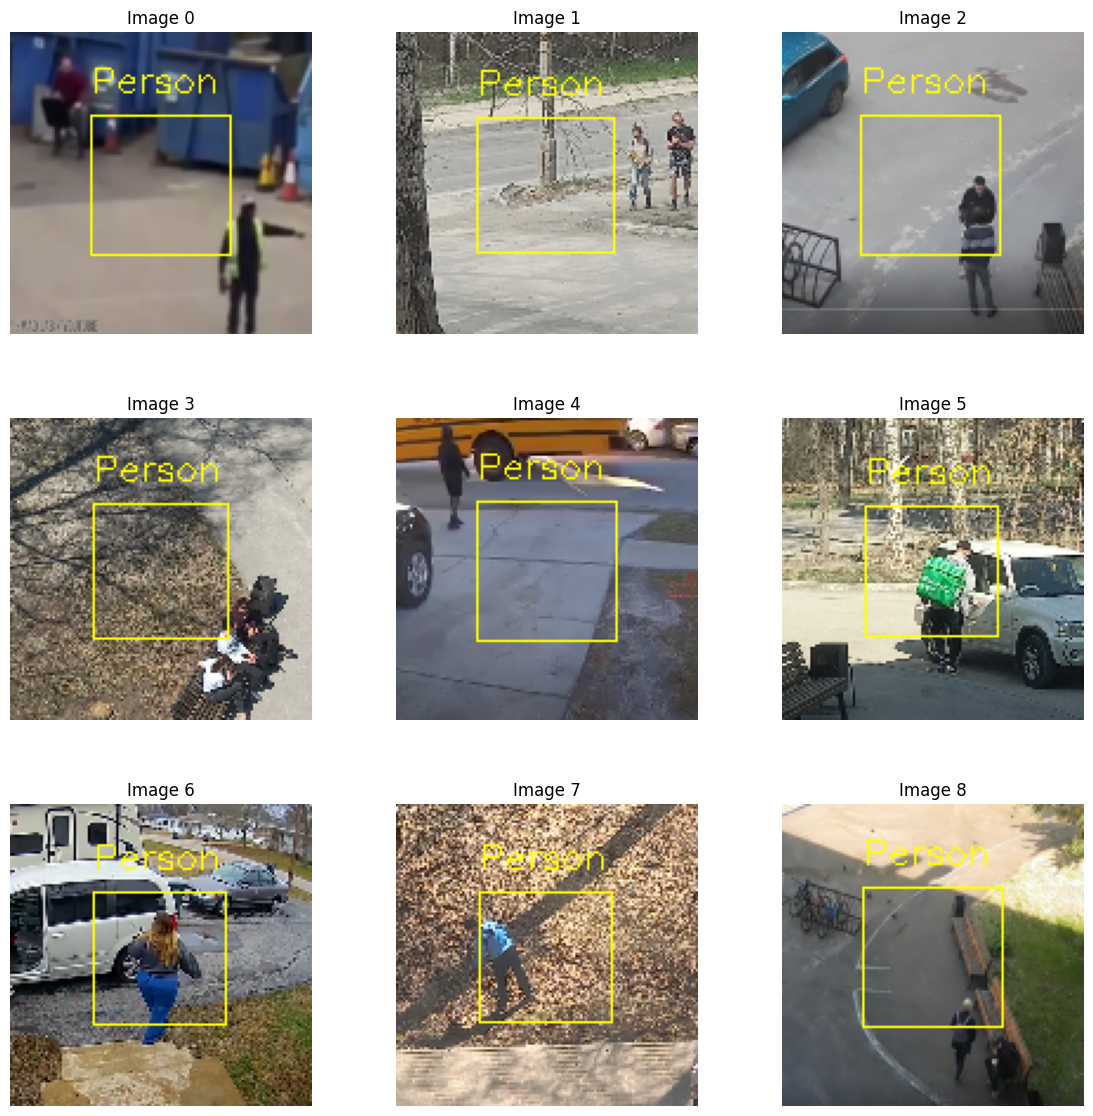

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
fig.tight_layout(pad=3.0)

for i in range(9):
    ax = axs[i // 3, i % 3]

    # Predict bounding box
    bboxs = model.predict(np.expand_dims(val_images_norm[i], axis=0))
    bbox = bboxs[0]

    # Draw predicted bounding box
    image_with_bbox = draw_bbox(val_images_norm[i], bbox, orig_shape=val_shapes[i], class_name='Person')

    # Show image
    ax.imshow(image_with_bbox)
    ax.axis("off")
    ax.set_title(f"Image {i}")

plt.show()


## Why SOTA Models Like YOLO Are Hard to Beat
While building your own model is a great learning experience, **matching the performance of SOTA models like YOLO, Faster R-CNN, or SSD is extremely difficult** due to:

- **Years of optimization and research** that went into designing these models.
- Pretrained weights trained on massive datasets (e.g., MS COCO).
- Advanced training strategies like multi-scale prediction, anchor box optimization, and label smoothing.
- Access to extensive computing power (e.g., multiple GPUs/TPUs during training).

In short: creating an object detection model from scratch that rivals YOLO in accuracy and speed is a **monumental task** — even for teams of researchers. But the good news is: **you don’t have to**.

## Transfer Learning: The Smart Way to Train with Your Dataset
Training a model from scratch requires a huge amount of data and compute power. That’s why modern computer vision projects often rely on transfer learning — a technique where a model pretrained on a large dataset (like COCO) is fine-tuned for a specific task (like detecting only "person").

### What is Transfer Learning?
Transfer learning takes a model that already understands general visual features (like edges, textures, and object parts) and adapts it to a new, smaller dataset. This allows the model to:

- Start with rich, pretrained features,
- Adapt quickly to your specific object(s),
- Work well with a limited number of training images,
- Achieve high accuracy in less time.

In this project, you're working with a YOLOv8 model that's **already fine-tuned** to detect a single object class — person — using a custom dataset. You’ll use it directly for inference, without needing to train it yourself.

> In the next section, you’ll dive deeper into the theory of transfer learning — how it works, why it’s effective, and when to apply it.

## Transfer Learning: Training YOLO on Your Own Dataset

In [ ]:
# === 6. Use YOLOv8 to run predictions ===
# TODO: Load a pretrained YOLOv8 model and perform inference

# Link to fine-tuned model: https://codefinity-content-media-v2.s3.eu-west-1.amazonaws.com/courses/ef049f7b-ce21-45be-a9f2-5103360b0655/object_detection_project/models/yolo_trained.pt
yolo_model = YOLO('https://codefinity-content-media-v2.s3.eu-west-1.amazonaws.com/courses/ef049f7b-ce21-45be-a9f2-5103360b0655/object_detection_project/models/yolo_trained.pt')

# Run YOLOv8 prediction on first 9 images from `val_images` with specified confidence treshold
yolo_results = yolo_model.predict([img for img in val_images[:9]], conf=0.5)

Found https://codefinity-content-media-v2.s3.eu-west-1.amazonaws.com/courses/ef049f7b-ce21-45be-a9f2-5103360b0655/object_detection_project/models/yolo_trained.pt locally at weights/yolo_trained.pt

0: 128x128 2 persons, 12.3ms
1: 128x128 2 persons, 12.3ms
2: 128x128 1 person, 12.3ms
3: 128x128 1 person, 12.3ms
4: 128x128 1 person, 12.3ms
5: 128x128 1 person, 12.3ms
6: 128x128 1 person, 12.3ms
7: 128x128 1 person, 12.3ms
8: 128x128 2 persons, 12.3ms
Speed: 0.5ms preprocess, 12.3ms inference, 0.3ms postprocess per image at shape (1, 3, 128, 128)


In [ ]:
hint6()


Step 6:
- Load a pretrained YOLOv8 model using the `YOLO` class.
- Set a confidence threshold for predictions (for example, 0.5) to filter low-confidence results.


In [ ]:
solution6()

yolo_model = YOLO ( 'https://codefinity-content-media-v2.s3.eu-west-1.amazonaws.com/courses/ef049f7b-ce21-45be-a9f2-5103360b0655/object_detection_project/models/yolo_trained.pt' ) 
 yolo_results = yolo_model . predict ([ img for img in val_images [: 9 ]], conf = 0.3 )

In [ ]:
check6(yolo_model)

YOLOv8 predictions and visualization are correct. Next key: LDB67X

## Vizualization

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
fig.tight_layout(pad=3.0)

for i in range(9):
    ax = axs[i // 3, i % 3]

    # Convert image to uint8 format for YOLO
    image = val_images[i].astype(np.uint8)

    # Draw bounding boxes
    image_with_yolo = draw_bbox(image, [yolo_results[i]], orig_shape=val_shapes[i])

    # Show image
    ax.imshow(image_with_yolo)
    ax.axis("off")
    ax.set_title(f"YOLOv8 - Image {i}")

plt.show()


## Evaluation

In [ ]:
# === 7. Predict on validation set and evaluate ===
# TODO: Generate predictions using the custom model and evaluate them.

pred_labels = model.predict(val_images)
evaluate_custom_model(val_labels, pred_labels)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 260ms/step
Mean Squared Error: 0.1957
Mean IoU: 0.0000
Precision @IoU=0.50: 0.0000
mAP@[0.50:0.95]: 0.0000


In [ ]:
hint7()


Step 7:
- Use your custom model to generate predictions on the validation set.
- Use the `evaluate_custom_model` function to calculate metrics like Mean Squared Error (MSE), mean IoU, precision, and mAP.
- Ensure that the predicted bounding boxes and the ground truth bounding boxes are in the same format.
- Consider IoU thresholds from 0.5 to 0.95 for mAP computation.


In [ ]:
solution7()

pred_labels = model . predict ( val_images_norm ) 
 evaluate_custom_model ( val_labels , pred_labels )

In [ ]:
check7(model, val_images, val_labels)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


Predictions generated and evaluation completed correctly. Next key: B55GT3

Make sure you've downloaded and extracted the dataset folder from the lesson. Inside that folder, you’ll find a file called `data.yaml`.

Open that file and make the following changes:

* After `train:`, insert the full path to your **training images folder** (e.g. `/content/drive/MyDrive/.../images/train`)
* After `val:`, insert the full path to your **validation images folder** (e.g. `/content/drive/MyDrive/.../images/val`)

Make sure the paths match the structure of your Google Drive exactly.

Once that's done, return to your notebook and replace `<path_to_data.yaml>` with the full path to your updated `data.yaml` file (e.g. `/content/drive/MyDrive/your_dataset_folder/data.yaml`). This will ensure the YOLO model can find everything it needs to run properly.


In [ ]:
# === 8. Evaluate YOLOv8 model ===
# TODO: Validate the YOLO model using the correct data.yaml file

metrics = yolo_model.val(data="/content/drive/MyDrive/dataset/data.yaml")

# TODO: Extract metrics from the `metrics` object

precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map = metrics.box.map

print("\nYOLO results:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"mAP50: {map50:.4f}")
print(f"mAP50-95: {map:.4f}")

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 1.3±1.3 ms, read: 18.4±21.9 MB/s, size: 162.7 KB)
val: Scanning /content/drive/MyDrive/dataset/labels/train.cache... 551 images, 142 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 693/693 111.8Mit/s 0.0s
val: /content/drive/MyDrive/dataset/images/train/131.png: ignoring corrupt image/label: negative class labels or coordinate [         -1          -1]
val: /content/drive/MyDrive/dataset/images/train/132.png: ignoring corrupt image/label: negative class labels or coordinate [         -1          -1]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 1.8it/s 24.1s
                   all        691        859      0.869      0.815      0.872      0.577
Speed: 0.1ms preprocess, 14.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val5

YOLO results:
Precision: 0.8686
Recall: 0

In [ ]:
hint8()


Step 8:
- Validate the YOLOv8 model by using the correct data.yaml file.
- Use the `yolo_model.val()` function to evaluate the model on the validation dataset.
- Extract metrics like precision, recall, mAP50, and mAP from the results.
- These metrics help in evaluating how well the YOLOv8 model performs on your dataset.


In [ ]:
solution8()

metrics = yolo_model . val ( data = "/path/to/dataset/directory/data.yaml" ) 

 precision = metrics . box . mp 
 recall = metrics . box . mr 
 map50 = metrics . box . map50 
 map = metrics . box . map 

 print ( " \n YOLO results:" ) 
 print ( f "Precision: { precision : .4f } " ) 
 print ( f "Recall: { recall : .4f } " ) 
 print ( f "mAP50: { map50 : .4f } " ) 
 print ( f "mAP50-95: { map : .4f } " )

In [ ]:
check8(metrics)

YOLO metrics extracted successfully. Here's your next key part: A777CS

## Conclusion

In this project, you implemented and compared **two different object detection approaches:**

### 1. Custom Object Detection CNN
You designed and trained your own convolutional neural network from scratch to predict bounding boxes in images.

**Pros:**

- Full control over the architecture and training process;
- Great for learning core concepts behind object detection;
- Lightweight compared to heavy pretrained models;
- Easier to adapt for unique or very small datasets.

**Cons:**

- Requires more data and compute power to reach high accuracy;
- Slower to train and tune manually;
- May not match the performance of pretrained models on complex tasks.

### 2. YOLO with Transfer Learning
You used **a fine-tuned YOLOv8 model**, which has been pretrained on a large dataset and adapted to your task.

**Pros:**

- State-of-the-art performance out of the box;
- Faster and more accurate on real-world data;
- Requires minimal training data and time (fine-tuning is already done);
- Easy to use with `ultralytics` library and robust tools.

**Cons:**

- Less flexible - architecture and training are abstracted away;
- Heavier models may not run efficiently on resource-limited devices;
- Harder to understand or customize without deep experience.

**Key Takeaways**

1. Building your own model helps you **understand the mechanics of object detection** and build a foundation in deep learning;
2. Using transfer learning with a pretrained model like YOLO is a powerful way to **achieve high performance quickly**;
3. In practice, a combination of both skills - understanding the fundamentals and knowing when to leverage transfer learning - is the most valuable.

